In [33]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

***AMAZON CASE***

In [34]:
tickers = "AMZN"
amzn = yf.Ticker(tickers)
data = amzn.history(start="2009-06-07", end="2010-06-07", interval="1d")
print(data.head())

                             Open    High     Low   Close     Volume  \
Date                                                                   
2009-06-08 00:00:00-04:00  4.3375  4.3590  4.2555  4.3180  112042000   
2009-06-09 00:00:00-04:00  4.3465  4.3835  4.3085  4.3540   89502000   
2009-06-10 00:00:00-04:00  4.3790  4.4280  4.2415  4.3295  121472000   
2009-06-11 00:00:00-04:00  4.3150  4.3745  4.2525  4.2845  100194000   
2009-06-12 00:00:00-04:00  4.2515  4.2600  4.1005  4.2040  124460000   

                           Dividends  Stock Splits  
Date                                                
2009-06-08 00:00:00-04:00        0.0           0.0  
2009-06-09 00:00:00-04:00        0.0           0.0  
2009-06-10 00:00:00-04:00        0.0           0.0  
2009-06-11 00:00:00-04:00        0.0           0.0  
2009-06-12 00:00:00-04:00        0.0           0.0  


In [35]:
close_prices = data['Close']
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

                       Date   Close
0 2009-06-08 00:00:00-04:00  4.3180
1 2009-06-09 00:00:00-04:00  4.3540
2 2009-06-10 00:00:00-04:00  4.3295
3 2009-06-11 00:00:00-04:00  4.2845
4 2009-06-12 00:00:00-04:00  4.2040


In [36]:
df_close.to_csv("/tmp/amzn_close_prices.csv", index=False)


In [37]:
df_amazon = pd.read_csv("/tmp/amzn_close_prices.csv")
df_amazon.head()

,Date,Close
0,2009-06-08 00:00:00-04:00,4.3180
1,2009-06-09 00:00:00-04:00,4.3540
2,2009-06-10 00:00:00-04:00,4.3295
3,2009-06-11 00:00:00-04:00,4.2845
4,2009-06-12 00:00:00-04:00,4.2040


/var/folders/62/rh9l84sx6d70_dkrpcr4kfbr0000gn/T/ipykernel_41164/2633157338.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_amazon['Date'] = pd.to_datetime(df_amazon['Date'])


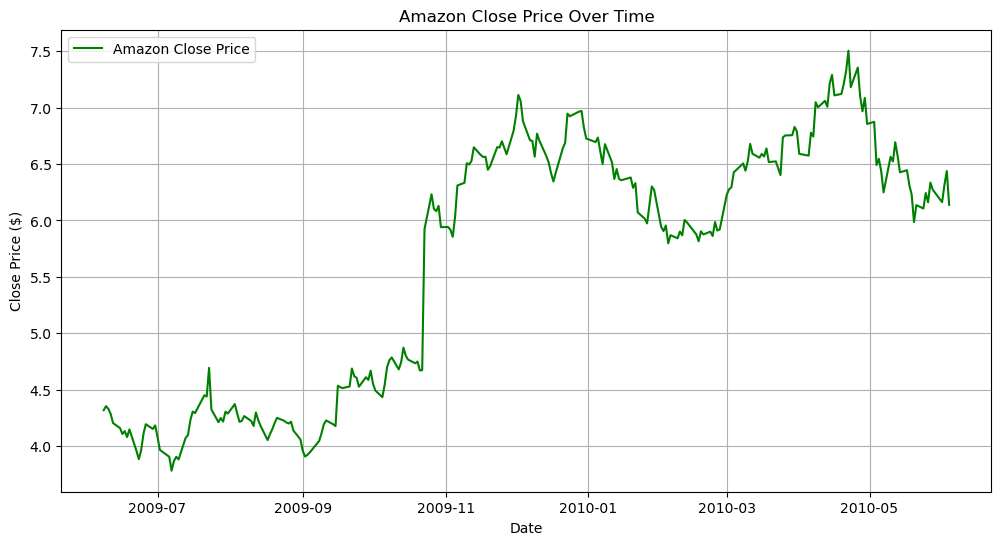

In [38]:
df_amazon['Date'] = pd.to_datetime(df_amazon['Date'])
df_amazon.set_index('Date', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_amazon.index, df_amazon['Close'], color ='green', label='Amazon Close Price')
plt.title('Amazon Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

***DATA COMPLETETENESS***

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2009-06-08 00:00:00-04:00 to 2010-06-04 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB


In [40]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02,251.0,251.0
mean,5.634396,5.714283,5.547420,5.636357,1.669595e+08,0.0,0.0
std,1.122262,1.139342,1.102231,1.118482,1.086537e+08,0.0,0.0
min,3.823000,3.896500,3.770500,3.781500,7.016000e+07,0.0,0.0
25%,4.332750,4.396750,4.267500,4.327000,1.122530e+08,0.0,0.0
50%,6.051500,6.215000,5.924500,6.071500,1.407520e+08,0.0,0.0
75%,6.553250,6.641250,6.478000,6.565000,1.818310e+08,0.0,0.0
max,7.350500,7.554500,7.294000,7.504500,1.166116e+09,0.0,0.0


In [41]:
data.shape

(251, 7)

In [42]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [43]:
print(f"The missing values in the dataset: {data['Close'].isnull().sum()}")

The missing values in the dataset: 0


In [44]:
total_rows = len(data)

missing_info = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percentage': (data.isnull().sum() / total_rows) * 100
})

print(missing_info)


              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


***DATA LATENCY***

In [45]:
min_close = data['Close'].min()
max_close = data['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 3.7815001010894775
Maximum Close Price: 7.504499912261963
Difference between Max and Min Close Price: 3.7229998111724854


***DATA CONSISTENCY***

In [46]:
print(data.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [47]:
print(data.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


***ERROR RATE***

In [48]:
missing_rate = data.isnull().mean() * 100
print(missing_rate)

Open            0.0
High            0.0
Low             0.0
Close           0.0
Volume          0.0
Dividends       0.0
Stock Splits    0.0
dtype: float64


In [49]:
duplicate_rate = data.duplicated().mean() * 100
print(duplicate_rate)

0.0


In [50]:
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data['Close'] < Q1 - 1.5 * IQR) | (data['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

0.0


***DATA ACCURACY***

In [51]:
minimum_price = data['Close'].min()
max_price = data['Close'].max()

print("The minimum recorded price is", minimum_price)

print("The maximum recorded price is", max_price)

The minimum recorded price is 3.7815001010894775
The maximum recorded price is 7.504499912261963


In [52]:
negative_price_count = (data['Close'] < 0).sum()
print("Number of records with negative Close price:", negative_price_count)

Number of records with negative Close price: 0


In [53]:
valid_close = data['Close'] > 0
valid_volume = data['Volume'] > 0
valid_dividends = data['Dividends'].notnull()

accurate_records = data[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [54]:
invalid_records = data[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")


❌ Invalid Value Rate: 0.00%


In [55]:
duplicate_rows = data.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [56]:
unit_price_accuracy = (data['Close'] > 0).sum() / len(data) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
